# Bảng điều khiển theo ngày — toàn bộ log (APS + APU)

Chọn 1 ngày, chạy, ra đầy đủ hình cho **cả 11 loại log** (6 loại cấp APS + 5
loại cấp APU). Sự kiện Error/Warning giờ là **biểu đồ tương tác** — di chuột
vào 1 chấm mới hiện tên lỗi, không còn chữ che kín biểu đồ. Sản lượng điện
hiển thị **theo từng giờ** (giờ nào phát nhiều/ít) thay vì đường cộng dồn.

> **Trước khi chạy:** đặt notebook cùng cấp với `cleaned_data/`. Cần cài thêm
> thư viện `plotly` (chạy 1 lần: `pip install plotly`).

> Đổi `SELECTED_DATE` ở cell cuối mỗi phần rồi chạy lại — không cần chạy lại
> từ đầu.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from pathlib import Path
import re

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

CLEANED_DIR = Path("cleaned_data")   # doi lai neu ban de o cho khac

def load_table(log_type_slug: str) -> pd.DataFrame:
    path = CLEANED_DIR / f"{log_type_slug}.csv"
    return pd.read_csv(path, parse_dates=["TimeStamp"])

print("San sang doc du lieu tu", CLEANED_DIR.resolve())

San sang doc du lieu tu D:\energy\PV\cleaned_data


## 0. Bảng tra cứu (mã lỗi/cảnh báo, OpState) — lấy từ tài liệu kỹ thuật hãng

In [12]:
ERROR_CODES_APS = {
    1: "Modbus TCP value out of range", 2: "Configuration corrupt",
    3: "APU 1/2 cooling fluid low", 4: "APU 3/4 cooling fluid low",
    5: "No enable signal", 6: "No supply voltage",
    7: "Medium voltage switch gear off", 8: "DI Temperature not OK",
    9: "DI medium voltage transformer error",
    10: "APU 1/2 water pump switching cycles", 11: "APU 3/4 water pump switching cycles",
    12: "APU 5/6 water pump switching cycles",
    13: "APU 1/2 air-to-air cooler switching cycles", 14: "APU 3/4 air-to-air cooler switching cycles",
    15: "APU 5/6 air-to-air cooler switching cycles",
    16: "APU 1/2 water air cooler switching cycles", 17: "APU 3/4 water air cooler switching cycles",
    18: "APU 5/6 water air cooler switching cycles",
    19: "Supply voltage low", 20: "Modbus TCP timeout",
    21: "APU 1/2 insulation", 22: "APU 3/4 insulation", 23: "APU 5/6 insulation",
    24: "Medium voltage transformer temperature high", 25: "APU 5/6 cooling fluid low",
    26: "Error count overrun",
    27: "APU 1/2 insulation monitor failed", 28: "APU 3/4 insulation monitor failed",
    29: "APU 5/6 insulation monitor failed",
    30: "APU 1 Powerlink", 31: "APU 2 Powerlink", 32: "APU 3 Powerlink",
    33: "APU 4 Powerlink", 34: "APU 5 Powerlink", 35: "APU 6 Powerlink",
    36: "APU 1 type mismatch", 37: "APU 2 type mismatch", 38: "APU 3 type mismatch",
    39: "APU 4 type mismatch", 40: "APU 5 type mismatch", 41: "APU 6 type mismatch",
    42: "APS unlicensed", 43: "Internal configuration not valid", 44: "APU Update",
    45: "APMC - Battery missing/empty",
    46: "APU1/2 Insulation Monitoring (pos. ground)", 47: "APU3/4 Insulation Monitoring (pos. ground)",
    48: "APU1/2 Insulation Monitoring (neg. ground)", 49: "APU3/4 Insulation Monitoring (neg. ground)",
    50: "APU1/2 extern Insulation Monitoring", 51: "APU3/4 extern Insulation Monitoring",
    53: "APU1/2 high Temperature", 54: "APU3/4 high Temperature",
    55: "APU1/2 Island Fuses", 56: "APU3/4 Island Fuses", 57: "Humidity too high",
}

ERROR_CODES_APU = {
    1: "Overtemperature IGBT L1", 2: "Overtemperature IGBT L2", 3: "Overtemperature IGBT L3",
    4: "Overtemperature inductance",
    5: "Overvoltage Vdc pos. SW", 6: "Overvoltage Vdc neg. SW", 7: "Overvoltage Vdc total SW",
    8: "Undervoltage Vdc pos. SW", 9: "Undervoltage Vdc neg. SW", 10: "Undervoltage Vdc total SW",
    11: "Overcurrent Idc SW", 12: "Overcurrent Iac L1 SW", 13: "Overcurrent Iac L2 SW",
    14: "Overcurrent Iac L3 SW", 16: "Grid rotation Error",
    17: "Overfrequency level 1", 18: "Overfrequency level 2", 19: "Overfrequency level 3",
    20: "Underfrequency level 1", 21: "Underfrequency level 2",
    22: "Overvoltage VL1 level 1", 23: "Overvoltage VL1 level 2", 24: "Overvoltage VL1 level 3",
    25: "Overvoltage VL2 level 1", 26: "Overvoltage VL2 level 2", 27: "Overvoltage VL2 level 3",
    28: "Overvoltage VL3 level 1", 29: "Overvoltage VL3 level 2", 30: "Overvoltage VL3 level 3",
    31: "Undervoltage VL1 level 1", 32: "Undervoltage VL1 level 2",
    33: "Undervoltage VL2 level 1", 34: "Undervoltage VL2 level 2",
    35: "Undervoltage VL3 level 1", 36: "Undervoltage VL3 level 2",
    37: "Driver L1", 38: "Driver L2", 39: "Driver L3",
    40: "Overcurrent Idc HW", 41: "Overcurrent Iac L1 HW", 42: "Overcurrent Iac L2 HW",
    43: "Overcurrent Iac L3 HW", 44: "Overtemperature IGBT HW",
    46: "Supply error", 47: "Supply error delayed",
    48: "Overvoltage Vdc neg. HW", 49: "Undervoltage Vdc neg. HW",
    50: "Overvoltage Vdc pos. HW", 51: "Undervoltage Vdc pos. HW", 52: "Overvoltage Vdc total HW",
    53: "Supply error 15V neg. SW", 54: "Supply error 15V pos. sum. SW",
    56: "Supply error 24V driver pos. SW", 57: "Supply error 24V neg. SW",
    58: "Supply error 24V pos. SW", 59: "Supply error 5V pos. SW",
    60: "AC switch", 61: "DC switch", 62: "Enable 24V",
    63: "Driver version L1", 64: "Driver version L2", 65: "Driver version L3",
    66: "CPLD version", 67: "HW control card", 68: "Model control card",
    69: "AC pre-charge", 70: "DC pre-charge", 71: "Sector synchronisation",
    72: "No sync. signal", 73: "Wrong firmware version", 74: "Wrong control mode",
    75: "Current sum error", 76: "Driver L1 (booster)", 77: "Driver L2 (booster)",
    78: "Driver L3 (booster)", 79: "Overcurrent Idc HW", 80: "Overcurrent Iac L1 HW",
    81: "Overcurrent Iac L2 HW", 82: "Overcurrent Iac L3 HW", 83: "PWM error",
    84: "Overvoltage Vdc neg. HW", 85: "Undervoltage Vdc neg. HW",
    86: "Overvoltage Vdc pos. HW", 87: "Undervoltage Vdc pos. HW", 88: "Overvoltage Vdc total HW",
    89: "Overtemperature IGBT HW", 90: "Overcurrent Booster HW", 91: "Driver Chopper",
    92: "Supply error", 93: "Supply error delayed", 94: "Driver Booster", 95: "No driver detected",
    96: "Overvoltage VL1 level 4", 97: "Overvoltage VL2 level 4", 98: "Overvoltage VL3 level 4",
    99: "Overvoltage mean level 1",
    100: "Overtemperature Control Card SW", 101: "Wrong version control card",
    102: "Voltage measurement Island grid", 103: "Unbalanced grid voltage",
    104: "Unbalanced phase angle", 105: "Unbalanced grid current",
    106: "Overcurrent Idc SW pos", 107: "Overcurrent Idc SW neg",
    108: "Undervoltage VL1 level 3", 109: "Undervoltage VL2 level 3", 110: "Undervoltage VL3 level 3",
    111: "Discharge Udc pos", 112: "Discharge Udc neg",
    113: "Wrong Op mode for overcurrent test", 114: "Wrong variant to Uac nom",
}

WARNING_CODES = {
    1: "APU 1/2 cooling fluid low", 2: "APU 3/4 cooling fluid low",
    3: "Time synchronisation failed", 4: "Modbus RTU (Display)",
    5: "AC surge arrester tripped", 6: "DC surge arrester tripped",
    7: "APU 1/2 insulation monitor failed", 8: "APU 3/4 insulation monitor failed",
    9: "APU 5/6 insulation monitor failed",
    10: "APU 1/2 insulation level 2", 11: "APU 3/4 insulation level 2", 12: "APU 5/6 insulation level 2",
    13: "APU 1/2 insulation level 1", 14: "APU 3/4 insulation level 1", 15: "APU 5/6 insulation level 1",
    22: "APU 1 error", 23: "APU 2 error", 24: "APU 3 error", 25: "APU 4 error",
    29: "APU 1 Powerlink", 30: "APU 2 Powerlink", 31: "APU 3 Powerlink", 32: "APU 4 Powerlink",
    35: "Power limit transformer", 36: "Power limit ambient",
    37: "APU 1 error counter overrun", 38: "APU 2 error counter overrun",
    39: "APU 3 error counter overrun", 40: "APU 4 error counter overrun",
    43: "APU in manual mode", 44: "Cooling in manual mode", 45: "Heating in manual mode",
    46: "APU in service mode", 47: "Log samples lost",
    48: "APU 1/2 current measurement", 49: "APU 3/4 current measurement",
    51: "APU 1/2 Powerlink flicker", 52: "APU 3/4 Powerlink flicker",
    54: "APU1/2 insulation monitoring (pos. ground)", 55: "APU3/4 insulation monitoring (pos. ground)",
    56: "APU1/2 insulation monitoring (neg. ground)", 57: "APU3/4 insulation monitoring (neg. ground)",
    58: "APU1/2 extern insulation monitoring", 59: "APU3/4 extern insulation monitoring",
    60: "USB-device almost full", 61: "USB-device full", 62: "CMB update", 63: "IMD update",
    64: "Max ModbusTCP master exceeded",
    65: "APU 1 disable", 66: "APU 2 disable", 67: "APU 3 disable", 68: "APU 4 disable",
    69: "USB-Device failed",
}

OPSTATE_MAP = {
    0: "Save energy", 30: "Booting", 50: "Off",
    100: "Initializing DC", 130: "Waiting (DC)", 160: "Precharging DC",
    200: "DC connection", 300: "AC connection status", 330: "Initializing AC",
    360: "Waiting (AC)", 400: "Precharging AC", 500: "AC connection",
    3000: "MPPT mode active", 10000: "Test bench mode",
}
print("Da nap bang tra cuu.")

Da nap bang tra cuu.


## 1. Hàm dùng chung

In [13]:
def _day_slice(df: pd.DataFrame, day) -> pd.DataFrame:
    day_start = pd.Timestamp(day)
    day_end = day_start + pd.Timedelta(days=1)
    return df[(df["TimeStamp"] >= day_start) & (df["TimeStamp"] < day_end)].sort_values("TimeStamp")

def _state_at_day_start(df: pd.DataFrame, day, value_cols, system=None):
    """Lay dong gan nhat TRUOC 00:00 ngay `day` (lam gia tri khoi dau cho
    bang trigger, tranh hien 'trong' tu dau ngay den lan thay doi dau tien)."""
    day_start = pd.Timestamp(day)
    before = df[df["TimeStamp"] < day_start]
    if system is not None and "System" in df.columns:
        before = before[before["System"] == system]
    if before.empty:
        return None
    last_row = before.sort_values("TimeStamp").iloc[[-1]].copy()
    last_row["TimeStamp"] = day_start
    return last_row[["TimeStamp"] + value_cols]

def melt_events(df: pd.DataFrame, cols, code_map: dict, id_vars=("TimeStamp",)) -> pd.DataFrame:
    id_vars = list(id_vars)
    cols = [c for c in cols if c in df.columns]
    if not cols or df.empty:
        return pd.DataFrame(columns=id_vars + ["Ma", "Mo ta"])
    long = df.melt(id_vars=id_vars, value_vars=cols, value_name="Ma")
    long = long[long["Ma"] != 0].copy()
    long["Ma"] = long["Ma"].astype(int)
    long["Mo ta"] = long["Ma"].map(code_map).fillna("Mã " + long["Ma"].astype(str))
    return long

def plot_event_timeline_interactive(events_df: pd.DataFrame, title: str,
                                     color_col: str = None, color_map: dict = None):
    """Bieu do tuong tac: moi cham la 1 su kien, DI CHUOT VAO moi hien mo ta
    (khong ghi chu san tren hinh, tranh che du lieu khi so luong lon)."""
    if events_df.empty:
        print(f"[{title}] Không có sự kiện nào trong ngày này.")
        return

    fig = go.Figure()
    if color_col and color_col in events_df.columns:
        groups = events_df[color_col].unique()
        for g in groups:
            sub = events_df[events_df[color_col] == g]
            fig.add_trace(go.Scatter(
                x=sub["TimeStamp"], y=[g] * len(sub), mode="markers",
                marker=dict(size=11, color=(color_map or {}).get(g)),
                text=sub["Mo ta"], hovertemplate="%{x}<br>%{text}<extra></extra>",
                name=str(g),
            ))
    else:
        fig.add_trace(go.Scatter(
            x=events_df["TimeStamp"], y=events_df.get("Nhom", ["Sự kiện"] * len(events_df)),
            mode="markers", marker=dict(size=11, color="#3778BF"),
            text=events_df["Mo ta"], hovertemplate="%{x}<br>%{text}<extra></extra>",
        ))

    fig.update_layout(title=title, height=260, margin=dict(l=80, r=20, t=40, b=30),
                       showlegend=bool(color_col))
    fig.show()

print("Da dinh nghia ham dung chung.")

Da dinh nghia ham dung chung.


## 2. Cấp APS — 6 loại log trong 1 ngày

In [14]:
def plot_aps_events(date_str: str):
    day = pd.Timestamp(date_str).normalize()
    trig_day = _day_slice(load_table("aps_stat_trig"), day)

    err_cols = [c for c in trig_day.columns if re.match(r"^Error\d+$", c)]
    warn_cols = [c for c in trig_day.columns if re.match(r"^Warning\d+$", c)]

    errs = melt_events(trig_day, err_cols, ERROR_CODES_APS)
    warns = melt_events(trig_day, warn_cols, WARNING_CODES)
    errs["Nhom"] = "Error"
    warns["Nhom"] = "Warning"
    events = pd.concat([errs, warns], ignore_index=True)

    plot_event_timeline_interactive(
        events, f"APS — Error/Warning ngày {day.date()} (di chuột vào chấm để xem mô tả)",
        color_col="Nhom", color_map={"Error": "red", "Warning": "#3778BF"}
    )

    if len(warns):
        print("Top Warning phổ biến nhất:")
        for desc, cnt in warns["Mo ta"].value_counts().head(5).items():
            print(f"  - {desc}: {cnt} lần")
    if len(errs):
        print("Top Error phổ biến nhất:")
        for desc, cnt in errs["Mo ta"].value_counts().head(5).items():
            print(f"  - {desc}: {cnt} lần")

In [15]:
def plot_aps_dashboard(date_str: str):
    day = pd.Timestamp(date_str).normalize()
    day_start, day_end = day, day + pd.Timedelta(days=1)

    aps_trig = load_table("aps_stat_trig")
    aps_ctrl = load_table("aps_ctrl_trig")
    aps60s = load_table("aps_stat_60s")
    aps_sw = load_table("aps_switching_cycles")
    aps_en = load_table("aps_energy")
    aps10s_path = CLEANED_DIR / "aps_stat_10s.csv"
    aps10s = load_table("aps_stat_10s") if aps10s_path.exists() else pd.DataFrame()

    fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True,
                              gridspec_kw={"height_ratios": [0.9, 1.3, 1.3, 1.6, 1.1]})
    ax_state, ax_temp, ax_riso, ax_ctrl, ax_energy = axes

    # OpState
    state_start = _state_at_day_start(aps_trig, day, ["OpState"])
    state_day = _day_slice(aps_trig, day)[["TimeStamp", "OpState"]] if "OpState" in aps_trig.columns else pd.DataFrame()
    state_all = pd.concat([state_start, state_day], ignore_index=True) if state_start is not None else state_day
    if len(state_all):
        state_all = state_all.sort_values("TimeStamp")
        ax_state.step(state_all["TimeStamp"], state_all["OpState"], where="post", color="#55A868")
        codes_present = sorted(state_all["OpState"].dropna().unique())
        ax_state.set_yticks(codes_present)
        ax_state.set_yticklabels([OPSTATE_MAP.get(int(c), str(c)) for c in codes_present], fontsize=8)
    ax_state.set_title("Trạng thái vận hành (OpState)", fontsize=11, loc="left")

    # Nhiet do
    temp_day = _day_slice(aps60s, day)
    for c, color in zip(["Tamb/°C", "Tpan/°C", "Ttrans/°C"], ["#4C72B0", "#DD8452", "#C44E52"]):
        if c in temp_day.columns:
            ax_temp.plot(temp_day["TimeStamp"], temp_day[c], label=c, color=color, linewidth=1)
    ax_temp.set_ylabel("°C")
    ax_temp.legend(fontsize=8, loc="upper right")
    ax_temp.set_title("Nhiệt độ môi trường / tấm pin / biến áp", fontsize=11, loc="left")

    # Cach dien
    riso_cols = [c for c in ["Riso12/k", "Riso34/kO", "Riso56/kO"] if c in temp_day.columns]
    cleak_cols = [c for c in ["Cleak12/µF", "Cleak34/µF", "Cleak56/µF"] if c in temp_day.columns]
    for c in riso_cols:
        ax_riso.plot(temp_day["TimeStamp"], temp_day[c], label=c, linewidth=1)
    ax_riso.set_ylabel("Riso (kΩ)")
    ax_riso.legend(fontsize=7, loc="upper left")
    if cleak_cols:
        ax_riso2 = ax_riso.twinx()
        for c in cleak_cols:
            ax_riso2.plot(temp_day["TimeStamp"], temp_day[c], label=c, linestyle="--", linewidth=1, alpha=0.6)
        ax_riso2.set_ylabel("Cleak (µF)")
        ax_riso2.legend(fontsize=7, loc="upper right")
    ax_riso.set_title("Điện trở cách điện & điện dung rò rỉ", fontsize=11, loc="left")

    # Trang thai dieu khien (Gantt)
    ctrl_state_cols = [c for c in ["WaterAir1State", "WaterAir2State", "WaterPump1", "WaterPump2",
                                    "DehumidifierOn", "HeatingOn", "EnableOn"] if c in aps_ctrl.columns]
    start_row = _state_at_day_start(aps_ctrl, day, ctrl_state_cols)
    ctrl_day = _day_slice(aps_ctrl, day)[["TimeStamp"] + ctrl_state_cols] if ctrl_state_cols else pd.DataFrame()
    ctrl_all = pd.concat([start_row, ctrl_day], ignore_index=True) if start_row is not None else ctrl_day
    if len(ctrl_all):
        ctrl_all = pd.concat([ctrl_all, pd.DataFrame({"TimeStamp": [day_end]})], ignore_index=True)
        ctrl_all = ctrl_all.sort_values("TimeStamp").ffill()
        t = ctrl_all["TimeStamp"].values
        for i, col in enumerate(ctrl_state_cols):
            on_mask = ctrl_all[col] > 0
            seg_start = None
            for j in range(len(ctrl_all)):
                if on_mask.iloc[j] and seg_start is None:
                    seg_start = t[j]
                elif not on_mask.iloc[j] and seg_start is not None:
                    ax_ctrl.barh(i, pd.Timestamp(t[j]) - pd.Timestamp(seg_start),
                                  left=pd.Timestamp(seg_start), height=0.6, color="#55A868")
                    seg_start = None
            if seg_start is not None:
                ax_ctrl.barh(i, day_end - pd.Timestamp(seg_start), left=pd.Timestamp(seg_start),
                              height=0.6, color="#55A868")
        ax_ctrl.set_yticks(range(len(ctrl_state_cols)))
        ax_ctrl.set_yticklabels(ctrl_state_cols, fontsize=8)
        ax_ctrl.set_ylim(-0.6, len(ctrl_state_cols) - 0.4)
    ax_ctrl.set_title("Trạng thái điều khiển (xanh = đang BẬT)", fontsize=11, loc="left")

    # San luong THEO TUNG GIO (lay sau tru truoc), khong phai cong don
    en_day = _day_slice(aps_en, day)
    if len(en_day) and "W_out_APS/kWh" in en_day.columns:
        en_day = en_day.copy()
        en_day["Delta_kWh"] = en_day["W_out_APS/kWh"].diff().clip(lower=0)
        hourly = en_day.set_index("TimeStamp")["Delta_kWh"].resample("1h").sum()
        ax_energy.bar(hourly.index, hourly.values, width=0.035, color="#4C72B0", align="edge")
        ax_energy.set_ylabel("kWh sản xuất / giờ")
    if len(aps10s):
        irr_day = _day_slice(aps10s, day)
        if len(irr_day) and "Irr/(W/m²)" in irr_day.columns and irr_day["Irr/(W/m²)"].notna().any():
            ax_irr = ax_energy.twinx()
            ax_irr.plot(irr_day["TimeStamp"], irr_day["Irr/(W/m²)"], color="orange", alpha=0.7,
                        label="Bức xạ Irr (W/m²)")
            ax_irr.set_ylabel("Irr (W/m²)")
            ax_irr.legend(loc="upper right", fontsize=8)
    ax_energy.set_title("Sản lượng điện THEO TỪNG GIỜ (giờ nào nhiều/ít)", fontsize=11, loc="left")
    ax_energy.set_xlabel("Giờ trong ngày")

    for ax in axes:
        ax.set_xlim(day_start, day_end)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
    fig.suptitle(f"APS — {day.date()}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

    if len(en_day) and "Delta_kWh" in en_day.columns:
        best_hour = hourly.idxmax()
        worst_hour = hourly[hourly > 0].idxmin() if (hourly > 0).any() else None
        print(f"[Insight] Giờ sản lượng cao nhất: {best_hour.strftime('%Hh')} "
              f"({hourly.max():,.0f} kWh)")
        if worst_hour is not None:
            print(f"[Insight] Giờ (có phát điện) thấp nhất: {worst_hour.strftime('%Hh')} "
                  f"({hourly[worst_hour]:,.0f} kWh)")

print("Da dinh nghia plot_aps_events() va plot_aps_dashboard().")

Da dinh nghia plot_aps_events() va plot_aps_dashboard().


**Chạy phần APS — đổi ngày rồi chạy lại cell này:**

Top Warning phổ biến nhất:
  - APU 3/4 insulation level 1: 35 lần
  - APU 1/2 insulation level 2: 27 lần
  - APU 1/2 insulation level 1: 22 lần
  - Log samples lost: 6 lần
  - APU 3/4 insulation level 2: 3 lần


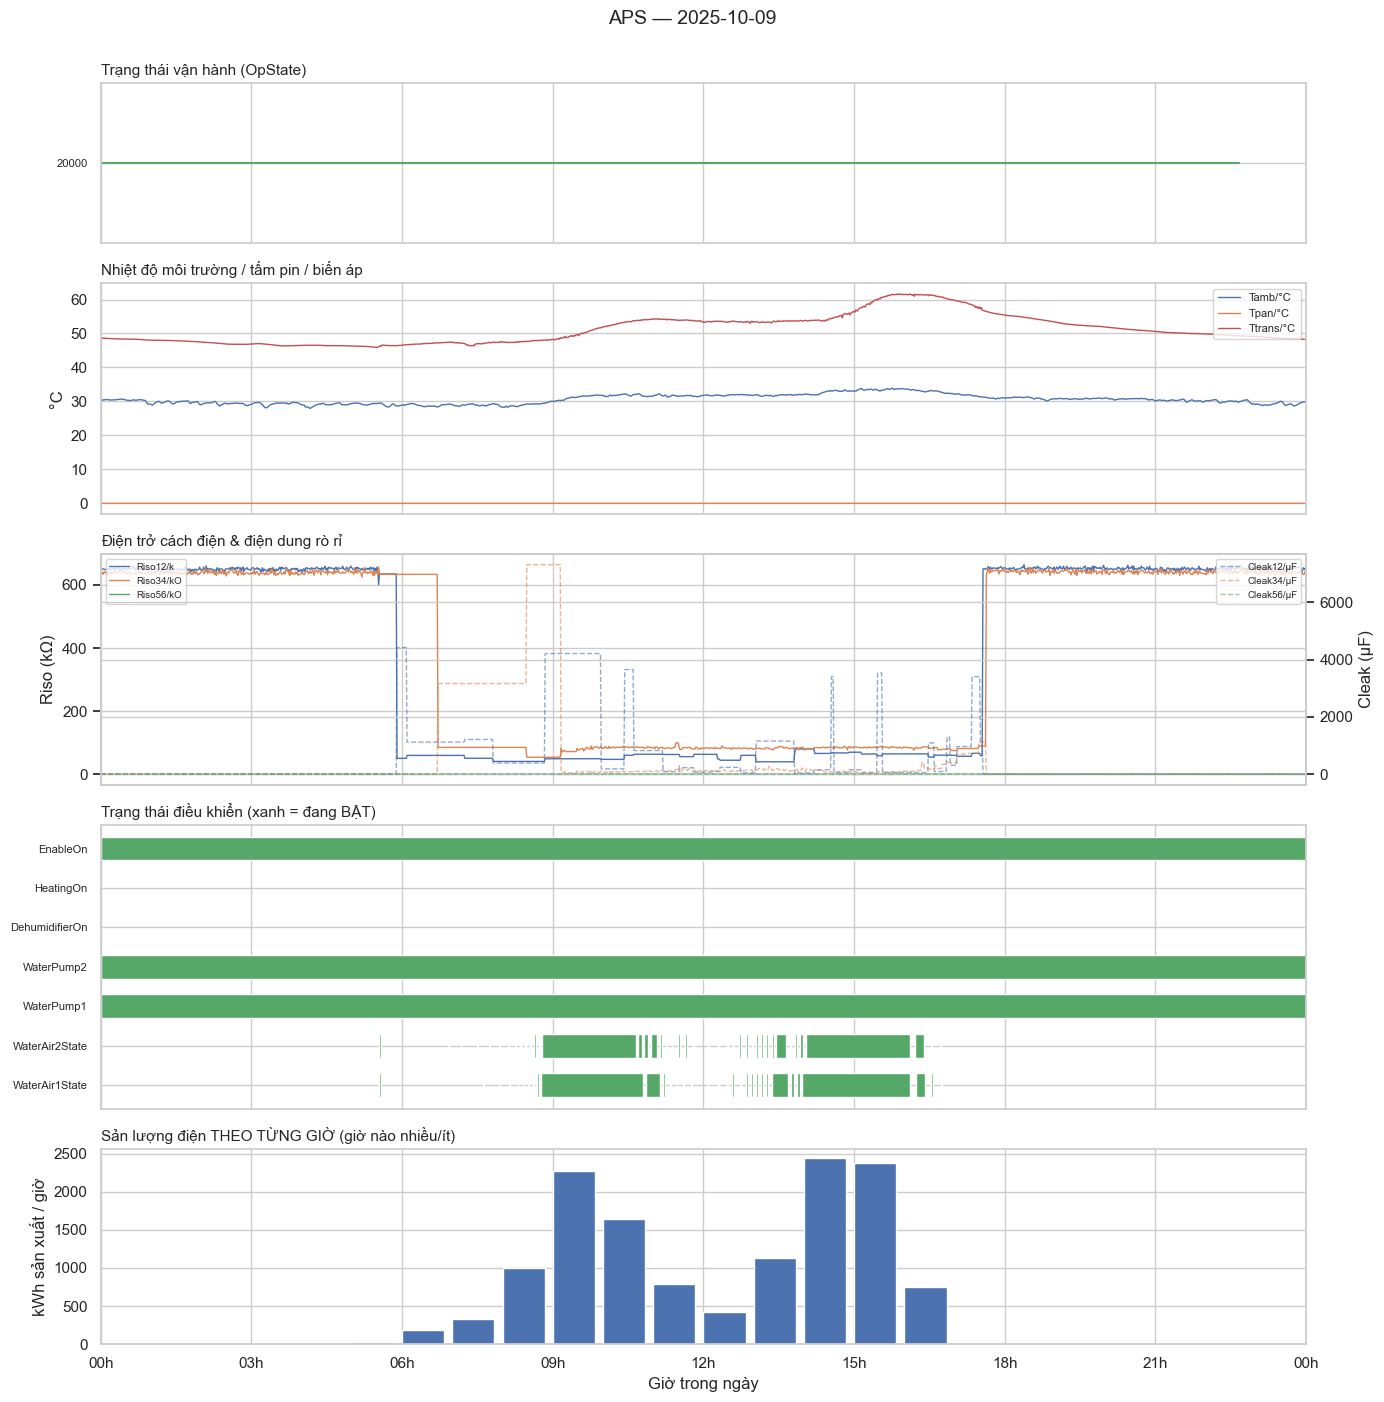

[Insight] Giờ sản lượng cao nhất: 14h (2,438 kWh)
[Insight] Giờ (có phát điện) thấp nhất: 17h (21 kWh)


In [25]:
SELECTED_DATE = "2025-10-09"   # DOI NGAY O DAY

plot_aps_events(SELECTED_DATE)
plot_aps_dashboard(SELECTED_DATE)

## 3. Cấp APU — 5 loại log trong 1 ngày, từng bộ biến tần

In [17]:
def plot_apu_events(date_str: str):
    day = pd.Timestamp(date_str).normalize()
    trig_day = _day_slice(load_table("apu_stat_trig"), day)
    err_cols = [c for c in trig_day.columns if re.match(r"^Error\d+$", c)]

    all_events = []
    for sysname, g in trig_day.groupby("System"):
        ev = melt_events(g, err_cols, ERROR_CODES_APU, id_vars=("TimeStamp",))
        ev["System"] = sysname
        all_events.append(ev)
    events = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()

    colors = {s: c for s, c in zip(sorted(trig_day["System"].unique()),
                                    ["#C44E52", "#DD8452", "#55A868", "#4C72B0"])}
    plot_event_timeline_interactive(
        events, f"APU — Error ngày {day.date()} (di chuột vào chấm để xem mô tả)",
        color_col="System", color_map=colors
    )
    if len(events):
        print("Top Error phổ biến nhất (tất cả APU):")
        for desc, cnt in events["Mo ta"].value_counts().head(5).items():
            print(f"  - {desc}: {cnt} lần")

print("Da dinh nghia plot_apu_events().")

Da dinh nghia plot_apu_events().


In [18]:
def plot_apu_power_env(date_str: str):
    """Cong suat, nhiet do, do am 4 APU trong 1 ngay (APU Stat 10s + 60s)."""
    day = pd.Timestamp(date_str).normalize()
    day_start, day_end = day, day + pd.Timedelta(days=1)

    stat10s_day = _day_slice(load_table("apu_stat_10s"), day)
    stat60s_day = _day_slice(load_table("apu_stat_60s"), day)
    systems = sorted(stat10s_day["System"].unique())
    palette = dict(zip(systems, sns.color_palette(n_colors=len(systems))))

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    ax_pdc, ax_temp, ax_hum = axes

    for sysname in systems:
        g = stat10s_day[stat10s_day["System"] == sysname]
        ax_pdc.plot(g["TimeStamp"], g["Pdc/kW"], label=sysname, color=palette[sysname], linewidth=0.8)
    ax_pdc.set_ylabel("Pdc (kW)")
    ax_pdc.legend(fontsize=8, ncol=4)
    ax_pdc.set_title("Công suất DC — 4 APU", fontsize=11, loc="left")

    for sysname in systems:
        g = stat60s_day[stat60s_day["System"] == sysname]
        if "TPCB/°C" in g.columns:
            ax_temp.plot(g["TimeStamp"], g["TPCB/°C"], label=sysname, color=palette[sysname], linewidth=0.8)
    ax_temp.set_ylabel("TPCB (°C)")
    ax_temp.set_title("Nhiệt độ bo mạch (TPCB) — 4 APU", fontsize=11, loc="left")

    for sysname in systems:
        g = stat60s_day[stat60s_day["System"] == sysname]
        if "Hum/%RH" in g.columns:
            ax_hum.plot(g["TimeStamp"], g["Hum/%RH"], label=sysname, color=palette[sysname], linewidth=0.8)
    ax_hum.set_ylabel("Độ ẩm (%RH)")
    ax_hum.set_title("Độ ẩm — 4 APU", fontsize=11, loc="left")
    ax_hum.set_xlabel("Giờ trong ngày")

    for ax in axes:
        ax.set_xlim(day_start, day_end)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
    fig.suptitle(f"APU — Công suất & môi trường — {day.date()}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

print("Da dinh nghia plot_apu_power_env().")

Da dinh nghia plot_apu_power_env().


In [19]:
def plot_apu_derating(date_str: str):
    """PLim vs cong suat thuc te, tung APU rieng (small multiples), trong 1 ngay."""
    day = pd.Timestamp(date_str).normalize()
    day_start, day_end = day, day + pd.Timedelta(days=1)

    stat10s_day = _day_slice(load_table("apu_stat_10s"), day)
    trig_day = _day_slice(load_table("apu_stat_trig"), day)
    systems = sorted(stat10s_day["System"].unique())

    pac_cols = [c for c in ["PL1/kW", "PL2/kW", "PL3/kW"] if c in stat10s_day.columns]
    plim_cols = [c for c in ["PL1Lim/kW", "PL2Lim/kW", "PL3Lim/kW"] if c in trig_day.columns]
    stat10s_day = stat10s_day.copy()
    stat10s_day["Pac_total_kW"] = stat10s_day[pac_cols].sum(axis=1)
    trig_day = trig_day.copy()
    trig_day["PLim_total_kW"] = trig_day[plim_cols].sum(axis=1) if plim_cols else np.nan

    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
    axes = axes.flatten()

    for ax, sysname in zip(axes, systems):
        left = stat10s_day[stat10s_day["System"] == sysname][["TimeStamp", "Pac_total_kW"]]
        right_start = _state_at_day_start(load_table("apu_stat_trig"), day, ["PL1Lim/kW", "PL2Lim/kW", "PL3Lim/kW"], system=sysname)
        right_day = trig_day[trig_day["System"] == sysname][["TimeStamp", "PLim_total_kW"]]
        if right_start is not None:
            right_start = right_start.copy()
            right_start["PLim_total_kW"] = right_start[plim_cols].sum(axis=1)
            right_start = right_start[["TimeStamp", "PLim_total_kW"]]
        right = pd.concat([right_start, right_day], ignore_index=True) if right_start is not None else right_day

        if left.empty or right.empty:
            ax.set_title(f"{sysname} (không đủ dữ liệu)")
            continue
        m = pd.merge_asof(left.sort_values("TimeStamp"), right.sort_values("TimeStamp"),
                           on="TimeStamp", direction="backward")
        ax.plot(m["TimeStamp"], m["Pac_total_kW"], label="Thực tế", linewidth=0.8)
        ax.plot(m["TimeStamp"], m["PLim_total_kW"], label="PLim", linewidth=0.8, linestyle="--")
        ax.fill_between(m["TimeStamp"], m["Pac_total_kW"], m["PLim_total_kW"],
                         where=(m["PLim_total_kW"] - m["Pac_total_kW"]) < m["PLim_total_kW"] * 0.05,
                         color="red", alpha=0.2)
        ax.set_title(sysname, fontsize=10)
        ax.legend(fontsize=7)
        ax.set_xlim(day_start, day_end)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))

    fig.suptitle(f"Công suất thực tế vs giới hạn PLim (vùng đỏ = đang bị kìm) — {day.date()}",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

print("Da dinh nghia plot_apu_derating().")

Da dinh nghia plot_apu_derating().


In [20]:
def plot_apu_energy_channels(date_str: str):
    """Dien luong sinh ra trong ngay theo tung kenh (string), tung APU."""
    day = pd.Timestamp(date_str).normalize()
    en_day = _day_slice(load_table("apu_energy"), day)
    pos_cols = [c for c in en_day.columns if c.endswith("pos/Ah")]

    rows = []
    for sysname, g in en_day.groupby("System"):
        for c in pos_cols:
            vals = g[c].dropna()
            if len(vals) < 2:
                continue
            rows.append({"System": sysname, "Kenh": c.replace(" pos/Ah", ""),
                         "Ah trong ngay": vals.max() - vals.min()})
    channel_day = pd.DataFrame(rows)

    if len(channel_day):
        fig, ax = plt.subplots(figsize=(14, 5))
        sns.barplot(data=channel_day, x="Kenh", y="Ah trong ngay", hue="System", ax=ax)
        ax.set_title(f"Điện lượng sinh ra TRONG NGÀY theo từng kênh — {day.date()}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        flagged = []
        for sysname, g in channel_day.groupby("System"):
            med = g["Ah trong ngay"].median()
            if med <= 0:
                continue
            low = g[g["Ah trong ngay"] < med * 0.7]
            for _, r in low.iterrows():
                flagged.append(f"{sysname}/{r['Kenh']}: {r['Ah trong ngay']:.2f} Ah (trung vị {med:.2f})")
        if flagged:
            print("[Insight] Kênh thấp bất thường trong ngày này (<70% trung vị cùng APU):")
            for f in flagged:
                print("  -", f)
        else:
            print("[Insight] Không có kênh nào lệch bất thường trong ngày này.")
    else:
        print("Không đủ dữ liệu APU Energy cho ngày này (bảng này có thể lấy mẫu thưa).")

print("Da dinh nghia plot_apu_energy_channels().")

Da dinh nghia plot_apu_energy_channels().


In [21]:
def plot_apu_ctrl(date_str: str):
    """Lenh dieu khien (APU Ctrl Trig): PSet tong va OpMode, tung APU."""
    day = pd.Timestamp(date_str).normalize()
    day_start, day_end = day, day + pd.Timedelta(days=1)

    ctrl = load_table("apu_ctrl_trig")
    pset_cols = [c for c in ["PSetL1/kW", "PSetL2/kW", "PSetL3/kW"] if c in ctrl.columns]
    systems = sorted(ctrl["System"].unique())

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    ax_pset, ax_mode = axes

    for sysname in systems:
        start = _state_at_day_start(ctrl, day, pset_cols + ["OpMode"], system=sysname)
        day_rows = _day_slice(ctrl[ctrl["System"] == sysname], day)[["TimeStamp"] + pset_cols + ["OpMode"]]
        allrows = pd.concat([start, day_rows], ignore_index=True) if start is not None else day_rows
        if allrows.empty:
            continue
        allrows = allrows.sort_values("TimeStamp")
        allrows["PSet_total_kW"] = allrows[pset_cols].sum(axis=1)
        ax_pset.step(allrows["TimeStamp"], allrows["PSet_total_kW"], where="post", label=sysname)
        ax_mode.step(allrows["TimeStamp"], allrows["OpMode"], where="post", label=sysname)

    ax_pset.set_ylabel("PSet tổng (kW)")
    ax_pset.legend(fontsize=8, ncol=4)
    ax_pset.set_title("Lệnh đặt công suất (PSet) — 4 APU", fontsize=11, loc="left")
    ax_mode.set_ylabel("OpMode")
    ax_mode.set_title("Chế độ vận hành (OpMode) — 4 APU", fontsize=11, loc="left")
    ax_mode.set_xlabel("Giờ trong ngày")

    for ax in axes:
        ax.set_xlim(day_start, day_end)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
    plt.tight_layout()
    plt.show()

print("Da dinh nghia plot_apu_ctrl().")

Da dinh nghia plot_apu_ctrl().


**Chạy phần APU — dùng chung `SELECTED_DATE` ở trên, chạy lại cell này:**

Top Error phổ biến nhất (tất cả APU):
  - Undervoltage Vdc total SW: 6 lần


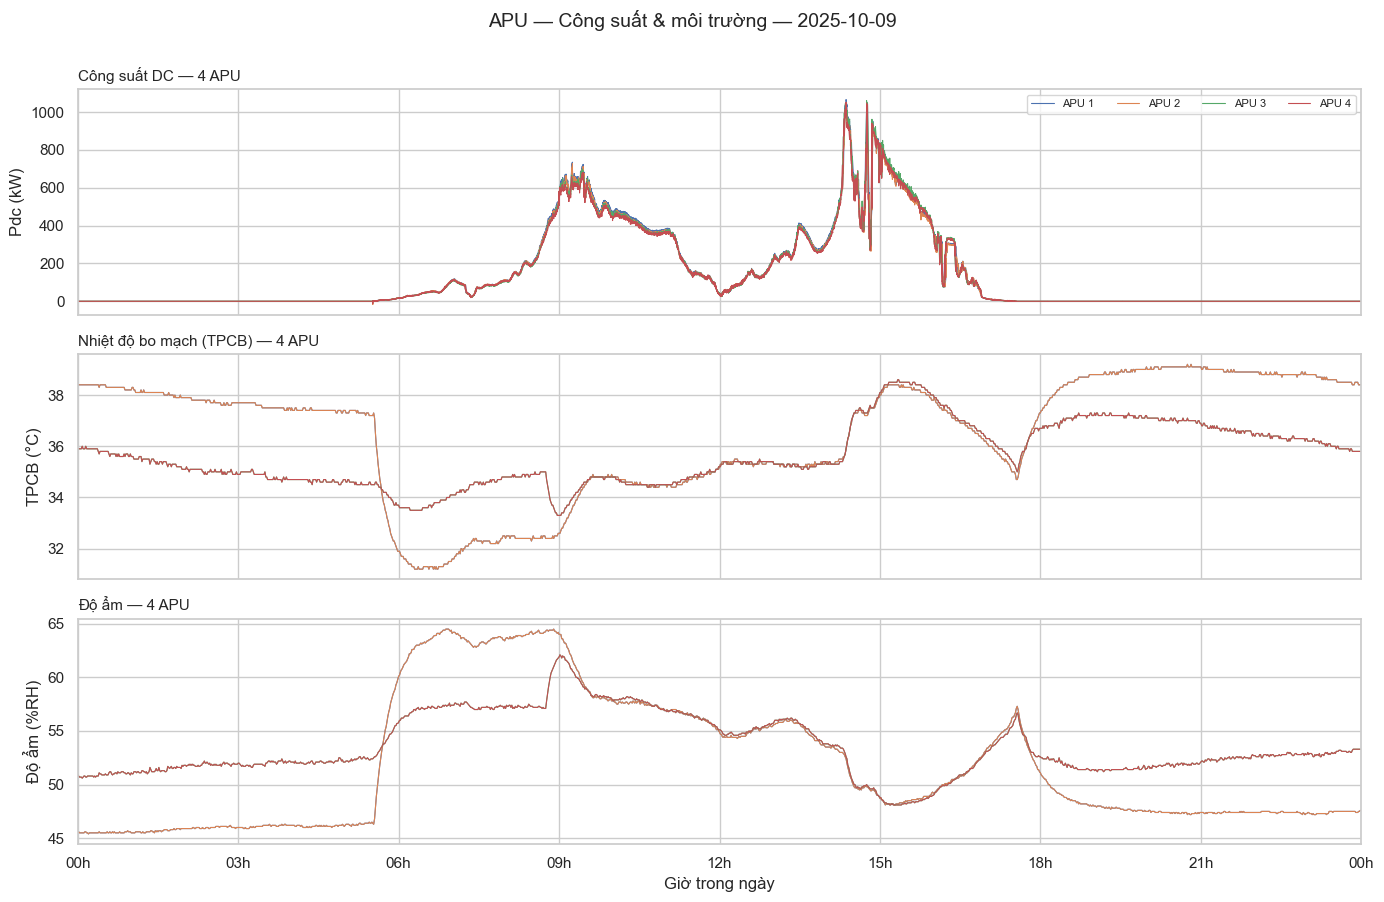

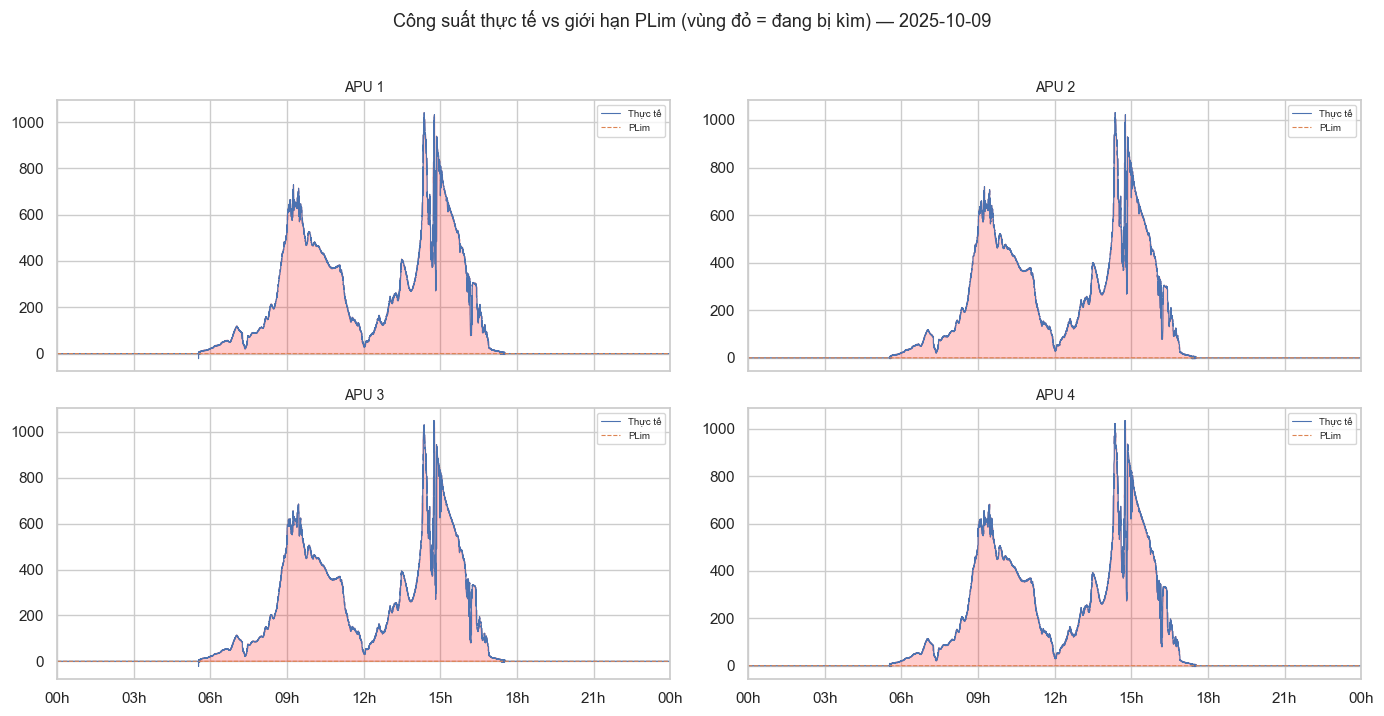

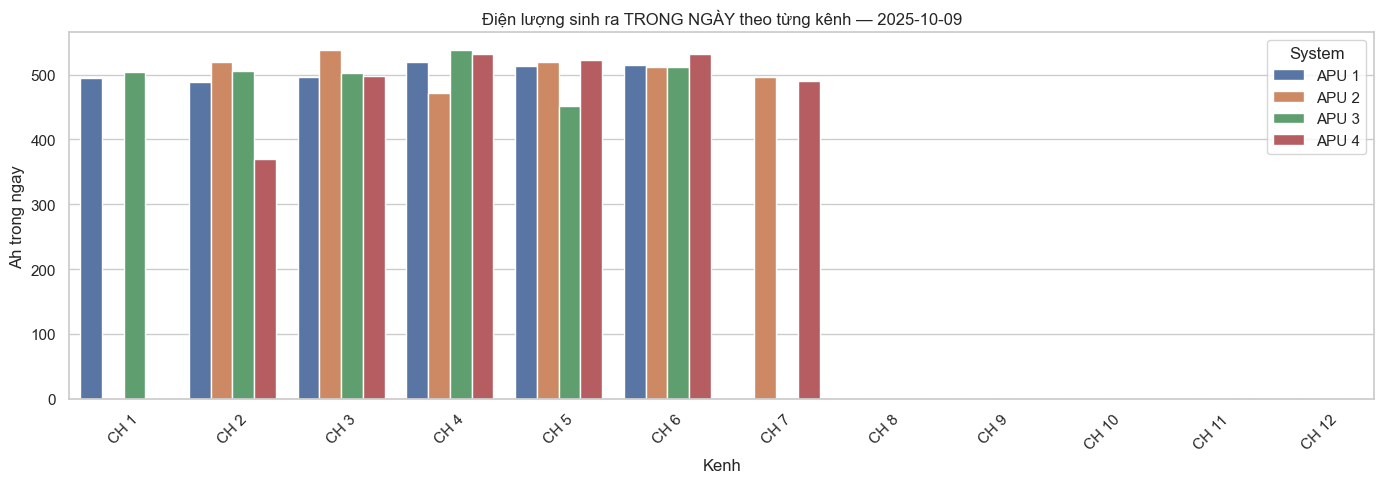

[Insight] Kênh thấp bất thường trong ngày này (<70% trung vị cùng APU):
  - APU 1/CH 7: 0.21 Ah (trung vị 244.79)
  - APU 1/CH 8: 0.40 Ah (trung vị 244.79)
  - APU 1/CH 9: 0.45 Ah (trung vị 244.79)
  - APU 1/CH 10: 0.57 Ah (trung vị 244.79)
  - APU 1/CH 11: 0.05 Ah (trung vị 244.79)
  - APU 1/CH 12: 0.03 Ah (trung vị 244.79)
  - APU 2/CH 1: 0.50 Ah (trung vị 235.81)
  - APU 2/CH 8: 0.45 Ah (trung vị 235.81)
  - APU 2/CH 9: 0.05 Ah (trung vị 235.81)
  - APU 2/CH 10: 0.02 Ah (trung vị 235.81)
  - APU 2/CH 11: 0.62 Ah (trung vị 235.81)
  - APU 2/CH 12: 0.45 Ah (trung vị 235.81)
  - APU 3/CH 7: 0.27 Ah (trung vị 225.80)
  - APU 3/CH 8: 0.49 Ah (trung vị 225.80)
  - APU 3/CH 9: 0.46 Ah (trung vị 225.80)
  - APU 3/CH 10: 0.60 Ah (trung vị 225.80)
  - APU 3/CH 11: 0.07 Ah (trung vị 225.80)
  - APU 3/CH 12: 0.03 Ah (trung vị 225.80)
  - APU 4/CH 1: 0.78 Ah (trung vị 185.39)
  - APU 4/CH 8: 0.57 Ah (trung vị 185.39)
  - APU 4/CH 9: 0.06 Ah (trung vị 185.39)
  - APU 4/CH 10: 0.03 Ah (trung vị 18

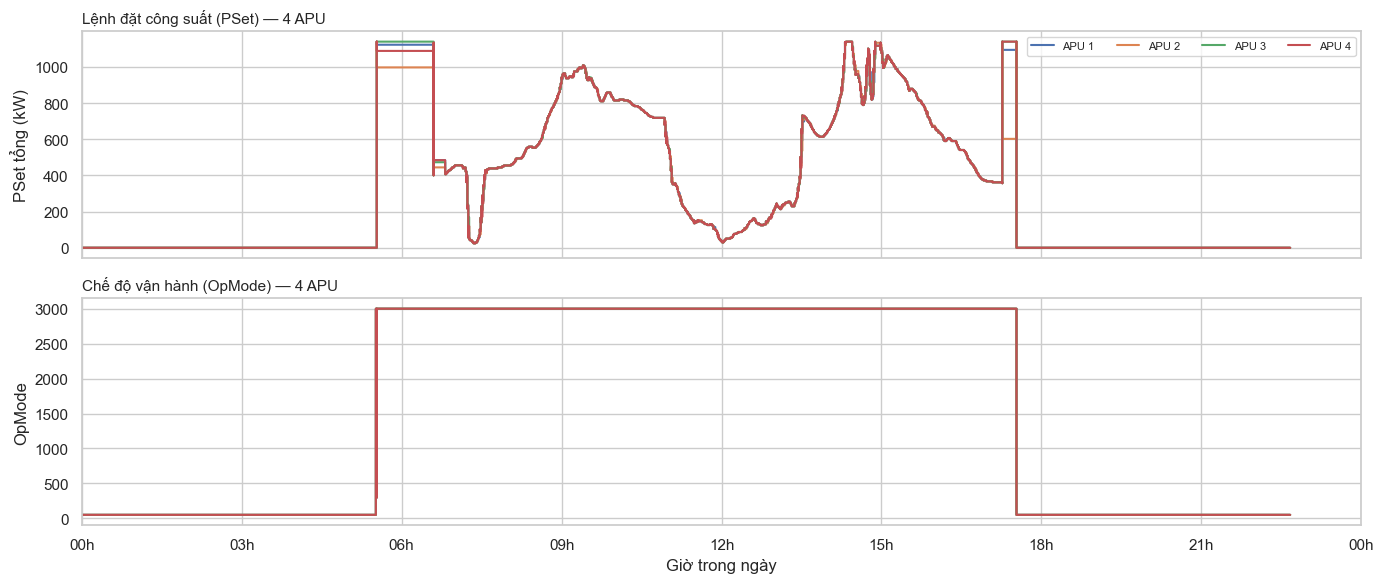

In [26]:
plot_apu_events(SELECTED_DATE)
plot_apu_power_env(SELECTED_DATE)
plot_apu_derating(SELECTED_DATE)
plot_apu_energy_channels(SELECTED_DATE)
plot_apu_ctrl(SELECTED_DATE)

## Tổng kết

- **Sự kiện Error/Warning (mục 2, 3):** di chuột vào từng chấm để xem tên lỗi
  thật — không còn chữ che dữ liệu; bảng xếp hạng bên dưới cho biết loại nào
  phổ biến nhất trong ngày.
- **Sản lượng theo giờ (mục 2):** giờ nào phát nhiều/ít nhất trong ngày, thay
  vì chỉ một đường cộng dồn khó so sánh.
- **Derating theo APU (mục 3):** vùng đỏ = đang bị kìm công suất, đối chiếu
  ngay với giờ nhiệt độ cao ở mục 2/3.
- **Kênh năng lượng (mục 3):** kênh nào sinh ra ít điện bất thường trong
  đúng ngày đang xem — dấu hiệu lỗi string PV.

Đổi `SELECTED_DATE` và chạy lại 2 cell "Chạy phần APS" / "Chạy phần APU" để
xem ngày khác — không cần chạy lại từ đầu.